# Rain-Plot-Inspired Bubble Matrix for Global ANOVA/FDR Results

This notebook reads the **master global-FDR CSV** created in the previous step and builds one publication-style bubble matrix.

### Visual encoding
- **Columns** = A vs B, A vs C, A vs D, A vs E
- **Rows** = gaze metrics grouped into CTA, Headline, Product
- **Bubble area** = effect size (`eta_sq`)
- **Bubble hue** = direction of change relative to A
  - one hue = higher than A
  - the other hue = lower than A
- **Thick black outline** = globally significant after BH-FDR (`q_global_FDR < .05`)
- **Small q-value label** = optional, only for globally significant cells

The figure is deliberately built on **one axes** rather than separate subplots, so the AOI groups remain visually comparable.


In [1]:
# Install once if needed:
# %pip install pandas matplotlib numpy

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


## 1. Configuration

In [2]:
INPUT_CSV = "A_vs_all_master_global_FDR.csv"

OUTPUT_PNG = "A_vs_all_bubble_matrix_global_FDR.png"
OUTPUT_PDF = "A_vs_all_bubble_matrix_global_FDR.pdf"
OUTPUT_PLOT_DATA = "A_vs_all_bubble_matrix_plot_data.csv"

ALPHA = 0.05

SHOW_Q_LABELS = True

COMPARISON_ORDER = ["A_vs_B", "A_vs_C", "A_vs_D", "A_vs_E"]
AOI_ORDER = ["CTA", "Headline", "Product"]

METRIC_ORDER = [
    "VAI (%)",
    "TTFF (s)",
    "Time spent (s)",
    "Fixations",
    "Fix. duration (s)",
    "FFD (s)",
    "K-coefficient",
    "Revisits",
]


## 2. Load and clean the master CSV

In [3]:
path = Path(INPUT_CSV)

if not path.exists():
    raise FileNotFoundError(
        f"Could not find {INPUT_CSV}. "
        "Put the master CSV in the same folder as this notebook "
        "or edit INPUT_CSV above."
    )

df = pd.read_csv(path)

# Remove accidental Markdown formatting such as **sd_A or **mean_C
df.columns = [
    str(c).replace("**", "").strip()
    for c in df.columns
]

for col in ["comparison", "AOI", "metric"]:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace("**", "", regex=False)
        .str.strip()
    )

numeric_cols = [
    "eta_sq",
    "p",
    "mean_A",
    "mean_C",
    "q_global_FDR",
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(
            df[col].astype(str)
                   .str.replace("**", "", regex=False)
                   .str.strip(),
            errors="coerce"
        )

if "significant_global_FDR" in df.columns:
    df["significant_global_FDR"] = (
        df["significant_global_FDR"]
        .astype(str)
        .str.strip()
        .str.lower()
        .isin(["true", "1", "yes", "y"])
    )

print("Rows loaded:", len(df))
print("Columns:", list(df.columns))


Rows loaded: 96
Columns: ['comparison', 'AOI', 'metric', 'eta_sq', 'p', 'df', 'n_A', 'n_C', 'mean_A', 'sd_A', 'mean_C', 'sd_C', 'F', 'levene_p', 'significant_raw', 'q_FDR', 'significant_FDR', 'eta_band', 'q_global_FDR', 'significant_global_FDR']


## 3. Validate the required columns

In [4]:
required = [
    "comparison",
    "AOI",
    "metric",
    "eta_sq",
    "mean_A",
    "mean_C",
    "q_global_FDR",
]

missing = [c for c in required if c not in df.columns]

if missing:
    raise ValueError(
        f"Missing required columns: {missing}\n"
        f"Available columns: {list(df.columns)}"
    )

expected = len(COMPARISON_ORDER) * len(AOI_ORDER) * len(METRIC_ORDER)

print("Expected tests:", expected)
print("Rows in file:", len(df))

if len(df) != expected:
    print(
        "WARNING: row count is not 96. "
        "The figure can still be generated, but check your master table."
    )


Expected tests: 96
Rows in file: 96


## 4. Calculate direction of change

In [5]:
# Your files use mean_C as the edited-condition mean even when the
# comparison is A_vs_B, A_vs_D, or A_vs_E.
# Direction is therefore simply edited-condition mean minus A mean.

df["mean_difference"] = df["mean_C"] - df["mean_A"]

df["direction"] = np.select(
    [
        df["mean_difference"] > 0,
        df["mean_difference"] < 0,
    ],
    [
        "Higher than A",
        "Lower than A",
    ],
    default="No change"
)

df["significant_global"] = df["q_global_FDR"] < ALPHA

df[
    [
        "comparison",
        "AOI",
        "metric",
        "mean_A",
        "mean_C",
        "mean_difference",
        "eta_sq",
        "q_global_FDR",
        "direction",
        "significant_global",
    ]
].head(12)


,comparison,AOI,metric,mean_A,mean_C,mean_difference,eta_sq,q_global_FDR,direction,significant_global
0,A_vs_B,CTA,VAI (%),19.2650,26.6800,7.4150,0.0588,0.301029,Higher than A,False
1,A_vs_B,CTA,TTFF (s),3.2989,2.9015,-0.3974,0.0401,0.436141,Lower than A,False
2,A_vs_B,CTA,Time spent (s),0.4535,0.5120,0.0585,0.0135,0.634119,Higher than A,False
3,A_vs_B,CTA,Fixations,15.3000,22.9500,7.6500,0.0471,0.381440,Higher than A,False
4,A_vs_B,CTA,Fix. duration (s),0.2778,0.2320,-0.0458,0.1459,0.064356,Lower than A,False
5,A_vs_B,CTA,FFD (s),0.2800,0.2345,-0.0455,0.1326,0.084343,Lower than A,False
6,A_vs_B,CTA,K-coefficient,0.2072,0.2530,0.0458,0.0025,0.843807,Higher than A,False
7,A_vs_B,CTA,Revisits,0.2110,0.3415,0.1305,0.0471,0.381440,Higher than A,False
8,A_vs_B,Headline,VAI (%),39.6100,48.2850,8.6750,0.1014,0.123977,Higher than A,False
9,A_vs_B,Headline,TTFF (s),1.6440,1.7375,0.0935,0.0042,0.789143,Higher than A,False


## 5. Prepare ordered plot data

In [6]:
plot_df = df[
    df["comparison"].isin(COMPARISON_ORDER)
    & df["AOI"].isin(AOI_ORDER)
    & df["metric"].isin(METRIC_ORDER)
].copy()

plot_df["comparison"] = pd.Categorical(
    plot_df["comparison"],
    categories=COMPARISON_ORDER,
    ordered=True
)

plot_df["AOI"] = pd.Categorical(
    plot_df["AOI"],
    categories=AOI_ORDER,
    ordered=True
)

plot_df["metric"] = pd.Categorical(
    plot_df["metric"],
    categories=METRIC_ORDER,
    ordered=True
)

plot_df = plot_df.sort_values(
    ["AOI", "metric", "comparison"]
).reset_index(drop=True)

plot_df.to_csv(OUTPUT_PLOT_DATA, index=False)

print(f"Saved plot-ready data: {OUTPUT_PLOT_DATA}")


Saved plot-ready data: A_vs_all_bubble_matrix_plot_data.csv


## 6. Build row positions for CTA, Headline, and Product

In [7]:
# One continuous y-axis with a small gap between AOIs.
row_positions = {}
row_labels = []
row_y = []

current_y = 0.0
AOI_GAP = 1.25

for aoi_i, aoi in enumerate(AOI_ORDER):
    for metric in METRIC_ORDER:
        key = (aoi, metric)
        row_positions[key] = current_y
        row_labels.append(metric)
        row_y.append(current_y)
        current_y += 1.0

    if aoi_i < len(AOI_ORDER) - 1:
        current_y += AOI_GAP

# x positions
x_positions = {
    comp: i for i, comp in enumerate(COMPARISON_ORDER)
}

print("Number of visual rows:", len(row_positions))


Number of visual rows: 24


## 7. Bubble-size mapping

In [8]:
# Area, not radius, represents eta-squared.
# This keeps visual comparisons more honest.

ETA_MIN = 0.0
ETA_MAX = max(0.40, float(plot_df["eta_sq"].max()))

SIZE_MIN = 28
SIZE_MAX = 850

def eta_to_area(eta):
    eta = np.clip(float(eta), ETA_MIN, ETA_MAX)
    scaled = (eta - ETA_MIN) / (ETA_MAX - ETA_MIN)
    return SIZE_MIN + scaled * (SIZE_MAX - SIZE_MIN)

plot_df["bubble_area"] = plot_df["eta_sq"].apply(eta_to_area)

plot_df[
    ["eta_sq", "bubble_area"]
].head()


,eta_sq,bubble_area
0,0.0588,136.032186
1,0.2119,417.320072
2,0.0274,78.341529
3,0.0890,191.518105
4,0.0401,101.675011


## 8. Create the publication figure

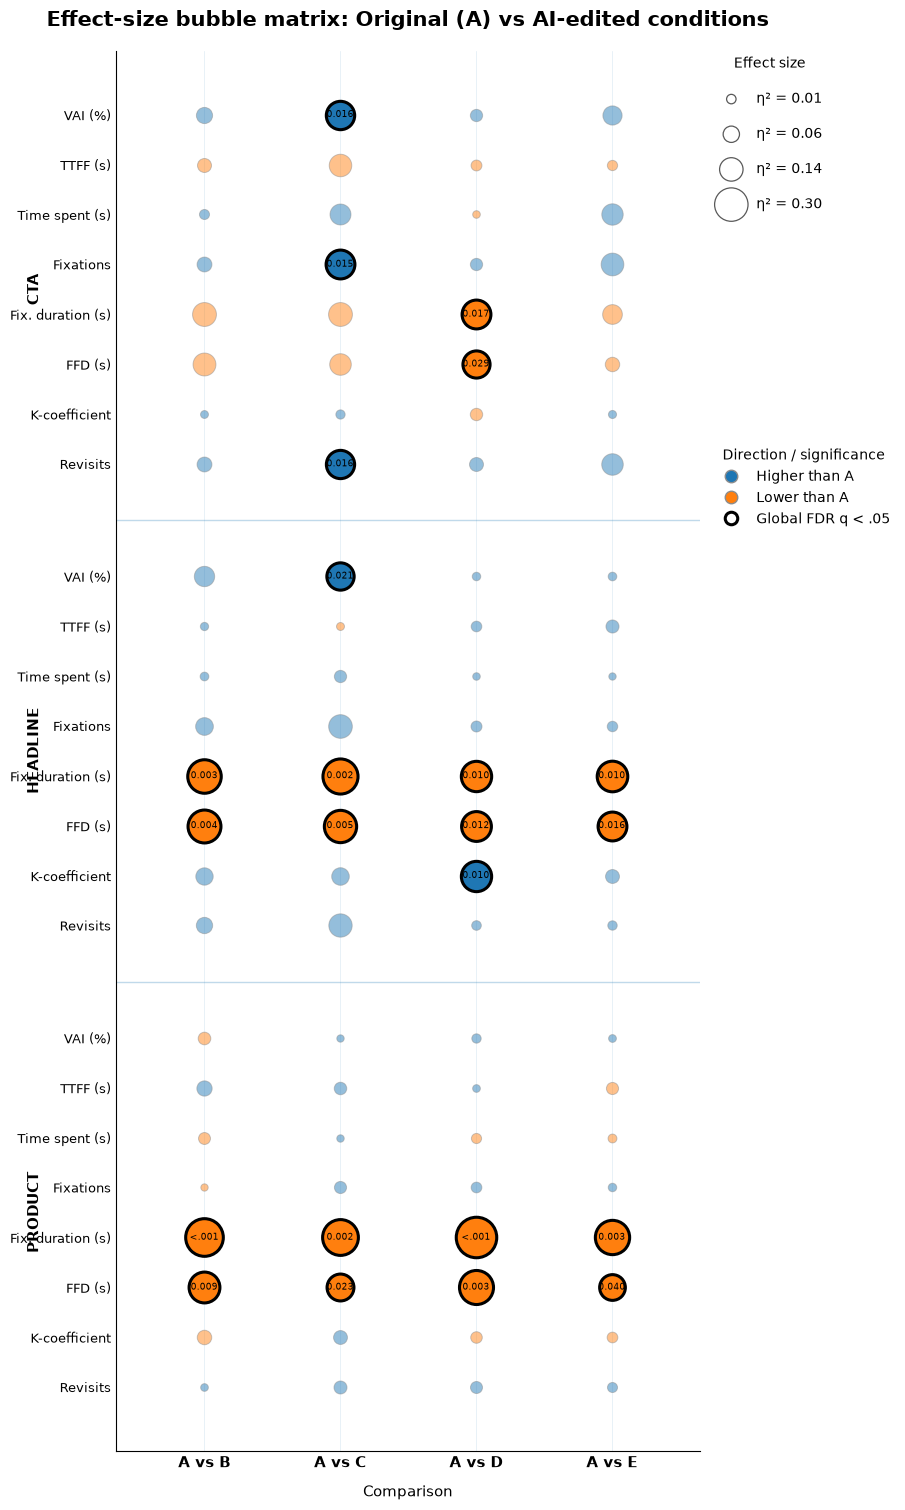

Saved PNG: A_vs_all_bubble_matrix_global_FDR.png
Saved PDF: A_vs_all_bubble_matrix_global_FDR.pdf


In [9]:
# Use the first two colors from the active Matplotlib color cycle.
# This keeps the notebook compatible with the user's existing Matplotlib theme.
cycle_colors = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])
if len(cycle_colors) < 2:
    cycle_colors = ["C0", "C1"]

direction_color = {
    "Higher than A": cycle_colors[0],
    "Lower than A": cycle_colors[1],
    "No change": "0.65",
}

fig, ax = plt.subplots(figsize=(9.2, 15.2))

# Draw all bubbles.
for _, r in plot_df.iterrows():
    x = x_positions[str(r["comparison"])]
    y = row_positions[(str(r["AOI"]), str(r["metric"]))]

    is_sig = bool(r["significant_global"])

    ax.scatter(
        x,
        y,
        s=r["bubble_area"],
        facecolor=direction_color[r["direction"]],
        edgecolor="black" if is_sig else "0.55",
        linewidth=2.2 if is_sig else 0.7,
        alpha=1.0 if is_sig else 0.48,
        zorder=3,
    )

    if SHOW_Q_LABELS and is_sig:
        q = float(r["q_global_FDR"])
        q_text = "<.001" if q < 0.001 else f"{q:.3f}"

        ax.text(
            x,
            y,
            q_text,
            ha="center",
            va="center",
            fontsize=6.6,
            zorder=4,
        )

# Axes
ax.set_xticks(range(len(COMPARISON_ORDER)))
ax.set_xticklabels(
    [c.replace("_", " ") for c in COMPARISON_ORDER],
    fontsize=11,
    fontweight="bold",
)

all_row_y = []
all_row_labels = []

for aoi in AOI_ORDER:
    for metric in METRIC_ORDER:
        all_row_y.append(row_positions[(aoi, metric)])
        all_row_labels.append(metric)

ax.set_yticks(all_row_y)
ax.set_yticklabels(all_row_labels, fontsize=9.5)

ax.invert_yaxis()

ax.set_xlim(-0.65, len(COMPARISON_ORDER) - 0.35)

# Light vertical guides
for x in range(len(COMPARISON_ORDER)):
    ax.axvline(
        x,
        linewidth=0.45,
        alpha=0.16,
        zorder=0,
    )

# AOI separators and labels
for aoi_i, aoi in enumerate(AOI_ORDER):
    ys = [
        row_positions[(aoi, metric)]
        for metric in METRIC_ORDER
    ]

    center_y = (min(ys) + max(ys)) / 2

    ax.text(
        -0.14,
        center_y,
        aoi.upper(),
        transform=ax.get_yaxis_transform(),
        rotation=90,
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
    )

    if aoi_i < len(AOI_ORDER) - 1:
        next_aoi = AOI_ORDER[aoi_i + 1]
        separator_y = (
            max(ys)
            + row_positions[(next_aoi, METRIC_ORDER[0])]
        ) / 2

        ax.axhline(
            separator_y,
            linewidth=1.0,
            alpha=0.28,
            zorder=1,
        )

ax.set_title(
    "Effect-size bubble matrix: Original (A) vs AI-edited conditions",
    fontsize=15,
    fontweight="bold",
    pad=18,
)

ax.set_xlabel(
    "Comparison",
    fontsize=11,
    labelpad=10,
)

ax.set_ylabel("")

# Size legend
legend_eta = [0.01, 0.06, 0.14, 0.30]

size_handles = [
    ax.scatter(
        [],
        [],
        s=eta_to_area(v),
        facecolor="none",
        edgecolor="0.35",
        linewidth=0.9,
        label=f"η² = {v:.2f}",
    )
    for v in legend_eta
]

legend1 = ax.legend(
    handles=size_handles,
    title="Effect size",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.00),
    frameon=False,
    borderaxespad=0,
    labelspacing=1.5,
)

ax.add_artist(legend1)

# Direction + significance legend
direction_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markersize=9,
        markerfacecolor=direction_color["Higher than A"],
        markeredgecolor="0.55",
        label="Higher than A",
    ),
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markersize=9,
        markerfacecolor=direction_color["Lower than A"],
        markeredgecolor="0.55",
        label="Lower than A",
    ),
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markersize=9,
        markerfacecolor="none",
        markeredgecolor="black",
        markeredgewidth=2.2,
        label="Global FDR q < .05",
    ),
]

ax.legend(
    handles=direction_handles,
    title="Direction / significance",
    loc="upper left",
    bbox_to_anchor=(1.02, 0.72),
    frameon=False,
    borderaxespad=0,
)

# Clean frame
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(axis="y", length=0)
ax.tick_params(axis="x", length=0)

fig.tight_layout()

fig.savefig(
    OUTPUT_PNG,
    dpi=400,
    bbox_inches="tight",
)

fig.savefig(
    OUTPUT_PDF,
    bbox_inches="tight",
)

plt.show()

print(f"Saved PNG: {OUTPUT_PNG}")
print(f"Saved PDF: {OUTPUT_PDF}")


## 9. How to read the figure

For each bubble:

- **Position** tells you the AOI, metric, and A-vs-condition comparison.
- **Area** tells you the magnitude of the ANOVA effect (`η²`).
- **Hue** tells you whether the edited condition mean is higher or lower than A.
- **Thick black outline** means the test survives the **global BH-FDR correction**.
- If `SHOW_Q_LABELS = True`, the number inside a significant bubble is the global FDR-adjusted `q` value.

Important: **higher/lower is not the same as better/worse.**  
For example, a lower TTFF means earlier attention, while a lower fixation duration has a different interpretation.


## 10. Optional: table of only globally significant bubbles

In [10]:
sig_table = (
    plot_df[plot_df["significant_global"]]
    [
        [
            "comparison",
            "AOI",
            "metric",
            "mean_A",
            "mean_C",
            "mean_difference",
            "eta_sq",
            "q_global_FDR",
            "direction",
        ]
    ]
    .sort_values(
        ["AOI", "metric", "comparison"]
    )
)

sig_table


,comparison,AOI,metric,mean_A,mean_C,mean_difference,eta_sq,q_global_FDR,direction
1,A_vs_C,CTA,VAI (%),19.2650,33.8700,14.6050,0.2119,0.016000,Higher than A
13,A_vs_C,CTA,Fixations,15.3000,33.5500,18.2500,0.2193,0.014720,Higher than A
18,A_vs_D,CTA,Fix. duration (s),0.2778,0.2221,-0.0557,0.2196,0.017179,Lower than A
22,A_vs_D,CTA,FFD (s),0.2800,0.2258,-0.0542,0.1926,0.028800,Lower than A
29,A_vs_C,CTA,Revisits,0.2110,0.5510,0.3400,0.2101,0.016000,Higher than A
33,A_vs_C,Headline,VAI (%),39.6100,51.6250,12.0150,0.1951,0.020640,Higher than A
48,A_vs_B,Headline,Fix. duration (s),0.2695,0.2190,-0.0505,0.3015,0.002743,Lower than A
49,A_vs_C,Headline,Fix. duration (s),0.2695,0.2150,-0.0545,0.3319,0.002400,Lower than A
50,A_vs_D,Headline,Fix. duration (s),0.2695,0.2247,-0.0448,0.2444,0.010338,Lower than A
51,A_vs_E,Headline,Fix. duration (s),0.2695,0.2217,-0.0478,0.2491,0.010338,Lower than A


## 11. Optional: strongest effects regardless of significance

In [11]:
plot_df[
    [
        "comparison",
        "AOI",
        "metric",
        "eta_sq",
        "q_global_FDR",
        "direction",
        "significant_global",
    ]
].sort_values(
    "eta_sq",
    ascending=False
).head(20)


,comparison,AOI,metric,eta_sq,q_global_FDR,direction,significant_global
82,A_vs_D,Product,Fix. duration (s),0.4474,0.000000,Lower than A,True
80,A_vs_B,Product,Fix. duration (s),0.3844,0.000000,Lower than A,True
81,A_vs_C,Product,Fix. duration (s),0.3460,0.002400,Lower than A,True
49,A_vs_C,Headline,Fix. duration (s),0.3319,0.002400,Lower than A,True
83,A_vs_E,Product,Fix. duration (s),0.3166,0.002743,Lower than A,True
86,A_vs_D,Product,FFD (s),0.3117,0.002743,Lower than A,True
48,A_vs_B,Headline,Fix. duration (s),0.3015,0.002743,Lower than A,True
52,A_vs_B,Headline,FFD (s),0.2905,0.003600,Lower than A,True
53,A_vs_C,Headline,FFD (s),0.2790,0.005333,Lower than A,True
84,A_vs_B,Product,FFD (s),0.2531,0.008640,Lower than A,True
